<img src='../OUTILS/bandeau_MF.png' align='right' width='100%'/>


<h1>Télécharger des données MTG à partir de l'EUMETSAT Data Access Client (Eumdac) et les visualiser.</h1>

## <a id='TOC-TOP'></a>Contenus

<div class="alert alert-block alert-warning">
    
<b>PREREQUIS </b>
    
Ce Notebook nécessite d'être enregistré auprès d'EUMETSAT, afin de pouvoir récupérer <em>login</em> et <em>mot de passe</em> dans les Informations d'identification de l'utilisateur "User credentials" </br>
(Une fois connecté, via cette page https://api.eumetsat.int/api-key/#) </br>
Le kernel "env_MF_teledetection" doit être utilisé.
</div>
<hr>

<div class="alert alert-info" role="alert">
    
<b>Utilisation de l'EUMETSAT Data Access Client (EUMDAC)</b>

EUMDAC est le client d'accès aux données d'EUMETSAT. Il permet d'accéder aux données EUMETSAT de diverses missions satellitaires. En tant que bibliothèque Python, elle propose de nombreuses méthodes et aides pour utiliser les API et services d'EUMETSAT, comme Data Store et Data Tailor. Elle propose également divers utilitaires en ligne de commande pour la recherche, le téléchargement et la personnalisation des données.</br>

Pour plus d'informations, consulter le guide d'Eumetsat : https://user.eumetsat.int/resources/user-guides/eumetsat-data-access-client-eumdac-guide


</div>

<div class="alert alert-info alert-success">
    
### 1 - Configuration nécessaire
</div>

### Télécharger la dernière version eumdac

Tout d'abord, importer les librairies nécessaires à ce TP.

In [1]:
from datetime import datetime
import sys
import os
import glob
from osgeo import gdal
from PIL import Image
import subprocess
from IPython.display import display,HTML
os.environ['PATH'] = f"/opt/conda/env_MF_teledetection/bin:{os.environ['PATH']}" 
os.environ['PATH'] = f"~/.conda/envs/env_MF_teledetection/bin:{os.environ['PATH']}"
os.environ['GDAL_DATA'] = '/opt/conda/env_MF_teledetection/share/gdal'
os.environ['PROJ_LIB'] = '/opt/conda/env_MF_teledetection/share/proj'

## Se positionner dans le répertoire MF_DATA_MANIPULATION

In [2]:
cd ~/MF_DATA_MANIPULATION

/home/coster/MF_DATA_MANIPULATION


Télécharger eumdac à partir du dépôt git d'eumetsat :

In [3]:
!git clone https://gitlab.eumetsat.int/eumetlab/data-services/eumdac.git

Cloning into 'eumdac'...
remote: Enumerating objects: 4435, done.
remote: Counting objects: 100% (1811/1811), done.
remote: Compressing objects: 100% (526/526), done.
remote: Total 4435 (delta 1285), reused 1811 (delta 1285), pack-reused 2624 (from 1)
Receiving objects: 100% (4435/4435), 1.87 MiB | 10.86 MiB/s, done.
Resolving deltas: 100% (3155/3155), done.


**Un répertoire "eumdac" est créé**.</br>Dans le cas d'une première utilisation, installer ensuite eumdac dans votre environnement via la commande "conda install -c eumetsat eumdac" </br>
(Non nécessaire pour ce TP)

### Utiliser vos identifiants afin de créer une clé (token), via l'une de ces 2 possibilités :
- Lancer cette commande : eumdac set-credentials <em>votre_login</em> <em>votre_mot_de_passe</em> > **Nous choisissons cette solution pour ce TP** </br>
- Créer un fichier .netrc sous votre home, en utilsant vos informations login et password que vous avez récupéré, contenant ces 3 lignes :</br>
machine api.eumetsat.int</br>
login <em>votre_login</em></br>
password <em>votre_mot_de_passe</em></br>


In [ ]:
eumdac set-credentials votre_login votre_mot_de_passe

In [4]:
!eumdac set-credentials ogQ9Mpf0f1GsPIyfg0w4md2ZJdsa b9uXQcvk7cmEMmRJ2S2kU90qq8oa #identifiant rudy coste

Credentials are correct. Token was generated: 6e200c54-28fb-3193-bbd9-dbc9248d7bf9
Credentials are written to file /home/coster/.eumdac/credentials


Si le Token a bien été généré, Eumdac est maintenant prêt à l'emploi


<div class="alert alert-info alert-success">
    
### 2 - Recherche et téléchargement de données MTG L1 :
</div>

Quelques liens utiles :  </br>
Catalogue des données Eumetsat : https://data.eumetsat.int/extended?query=mtg  </br>
FCI Level 1c Normal Resolution Image Data - MTG - 0 degree : https://data.eumetsat.int/data/map/EO:EUM:DAT:0662  </br>
FCI Level 1c High Resolution Image Data - MTG - 0 degree   : https://data.eumetsat.int/data/map/EO:EUM:DAT:0665

Obtenir les produits récents d'une collection spécifique</br>
Pour obtenir les produits récents d'une collection, spécifiez l'ID de la collection dans la commande ci-dessous.

Visualisation des 5 derniers fichiers Normal Resolution disponibles

In [5]:
!eumdac search -c EO:EUM:DAT:0662 --limit 5

W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250928090258_IDPFI_OPE_20250928090006_20250928090927_N__O_0055_0000
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250928085254_IDPFI_OPE_20250928085006_20250928085927_N__O_0054_0000
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250928084255_IDPFI_OPE_20250928084006_20250928084927_N__O_0053_0000
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250928083250_IDPFI_OPE_20250928083006_20250928083927_N__O_0052_0000
W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250928082251_IDPFI_OPE_20250928082006_20250928082927_N__O_0051_0000


### Nombreuses options disponibles... 
eumdac describe</br>
eumdac search -c EO:EUM:DAT:0662 -p <em>nom_du_fichier</em>              #Recherche d'un fichier </br>
eumdac search -c EO:EUM:DAT:0662 --limit 5                               #Recherche des 5 derniers fichiers
eumdac download -c EO:EUM:DAT:0662 --limit 3                             #Téléchargement des 10 derniers fichiers </br>
eumdac download -c EO:EUM:DAT:0662 --limit 3 --threads 5                 #Téléchargement en parallélisant le flux (gain de temps si la bande le permet...) </br>
eumdac download -c EO:EUM:DAT:0662 -p nom_du_fichier                     #Téléchargement d'un fichier</br>
eumdac download -c EO:EUM:DAT:0662 --start 2025-05-14T10:00:00 --end 2025-05-14T10:10:00  #Téléchargement d'une date particulière (ici le 14/05/2025 à 10 h 00 UTC)</br>
eumdac download -c EO:EUM:DAT:0662 --limit 1 --entry '*0037.nc'          #Téléchargement, pour le dernier fichier, seulement du chunk numéro 37


Plus de renseignements sur cette page : https://user.eumetsat.int/resources/user-guides/eumetsat-data-access-client-eumdac-guide

Téléchargement seulement un chunk pour le dernier fichier FCI Level 1c Normal Resolution Image Data - MTG - 0 degree

In [6]:
cd ~/MF_DATA_MANIPULATION

/home/coster/MF_DATA_MANIPULATION


In [7]:
pwd

'/home/coster/MF_DATA_MANIPULATION'

In [8]:
output_folder = 'CHUNKS'
os.makedirs(output_folder, exist_ok=True)

Exemple pour télécharger le chunk "Normal Resolution", numéro 22, pour le 14/05/2025 à 10 h UTC, sur la zone nord de la République démocratique du Congo. </br>
Les données seront téléchargées dans ~/MF_DATA_MANIPULATION/CHUNKS/

In [9]:
!eumdac download -c EO:EUM:DAT:0662 --start 2025-05-14T10:00:00 --end 2025-05-14T10:10:00 --entry '*0022.nc' --output ~/MF_DATA_MANIPULATION/CHUNKS/

Processing 1 product.
Using order: 2025-09-28#0001
Output directory: /home/coster/MF_DATA_MANIPULATION/CHUNKS
Job 1: Preparing download of W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250514100343_IDPFI_OPE_20250514100007_20250514100935_N__O_0061_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514100806_IDPFI_OPE_20250514100451_20250514100540_N__O_0061_0022.nc, splitting in 1 chunks.
Job 1: Download complete: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250514100343_IDPFI_OPE_20250514100007_20250514100935_N__O_0061_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514100806_IDPFI_OPE_20250514100451_20250514100540_N__O_0061_0022.nc, current speed: 26.75 MB/s
Removing successfully finished order 2025-09-28#0001


<div class="alert alert-info alert-success">
    
### 3 - Lire le contenu des métadonnées avec GDAL
</div>


les noms des dossiers/fichiers téléchargés étant très longs, nous les mettons dans des variables pour plus de lisibilité

In [22]:
repertoire='CHUNKS/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250514100343_IDPFI_OPE_20250514100007_20250514100935_N__O_0061_0000'
fichier='W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514100806_IDPFI_OPE_20250514100451_20250514100540_N__O_0061_0022.nc'
rep_resultat='~/MF_DATA_MANIPULATION/RESULTS'

Création du répertoire RESULTS

In [20]:
output_folder = 'RESULTS'
os.makedirs(output_folder, exist_ok=True)

In [23]:
!gdalinfo {repertoire}/{fichier}

Driver: netCDF/Network Common Data Format
Files: CHUNKS/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250514100343_IDPFI_OPE_20250514100007_20250514100935_N__O_0061_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514100806_IDPFI_OPE_20250514100451_20250514100540_N__O_0061_0022.nc
Size is 512, 512
Metadata:
  /data/ir_105/NC_GLOBAL#long_name=FCI FDHSI Infrared 10.5 micron channel
  /data/ir_105/NC_GLOBAL#subsettable=yes
  /data/ir_105/quality_channel/NC_GLOBAL#long_name=Quality indicators applicable to a particular channel for the data chunk
  /data/ir_105/swath/NC_GLOBAL#long_name=Swath related information
  /data/ir_123/NC_GLOBAL#long_name=FCI FDHSI Infrared 12.3 micron channel
  /data/ir_123/NC_GLOBAL#subsettable=yes
  /data/ir_123/quality_channel/NC_GLOBAL#long_name=Quality indicators applicable to a particular channel for the data chunk
  /data/ir_123/swath/NC_GLOBAL#long_name=Swath related information
  /dat

**gdalinfo d'un seul "Subdataset" : /data/vis_06/measured/effective_radiance**

In [24]:
!gdalinfo NETCDF:"{repertoire}/{fichier}":/data/vis_06/measured/effective_radiance

Warning 1: Unhandled X/Y axis unit radian. SRS will ignore axis unit and be likely wrong.
Driver: netCDF/Network Common Data Format
Files: CHUNKS/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250514100343_IDPFI_OPE_20250514100007_20250514100935_N__O_0061_0000/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20250514100806_IDPFI_OPE_20250514100451_20250514100540_N__O_0061_0022.nc
Size is 11136, 278
Coordinate System is:
PROJCRS["unnamed",
    BASEGEOGCRS["unknown",
        DATUM["unnamed",
            ELLIPSOID["Spheroid",6378137,298.25722356301,
                LENGTHUNIT["metre",1,
                    ID["EPSG",9001]]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433,
                ID["EPSG",9122]]]],
    CONVERSION["Geostationary Satellite (Sweep Y)",
        METHOD["Geostationary Satellite (Sweep Y)"],
        PARAMETER["Longitude of natural origin",0,
            ANGLEUNIT["degree",0.0

<div class="alert alert-info alert-success">
    
### 4 - Etraire le "Subdataset", et créer un fichier image
</div>


In [ ]:
!gdal_translate -scale 0 10000 0 255 -ot byte NETCDF:{repertoire}/{fichier}:/data/vis_06/measured/effective_radiance {rep_resultat}/chunk_brute.tif

Eclaircissement avec augmentation du gamma de l'image (trop sombre)

In [ ]:
!gdal_translate {rep_resultat}/chunk_brute.tif {rep_resultat}/chunk.tif -scale -exponent 0.5

Et la convertir en jpg (plus léger et rapide à visualiser)

Et conversion en format jpg plus léger

In [ ]:
!magick {rep_resultat}/chunk.tif {rep_resultat}/chunk.jpg

In [ ]:
#se positionner dans le répertoire ~/MF_DATA_MANIPULATION si ce n'est pas déjà fait

In [ ]:
cd ~/MF_DATA_MANIPULATION

In [63]:
output = "RESULTS/"  # dossier de sortie
im = Image.open(output + 'chunk.jpg', 'r')
display(im)

FileNotFoundError: [Errno 2] No such file or directory: 'RESULTS/chunk.jpg'

## Télécharger plus de chunks, par exemple tous les chunks entre 20 et 29 :

In [ ]:
!eumdac download -c EO:EUM:DAT:0662 --start 2025-05-14T10:00:00 --end 2025-05-14T10:10:00 --entry '*002?.nc' --output ~/MF_DATA_MANIPULATION/CHUNKS/

In [ ]:
repertoire_chunks_20a29='CHUNKS/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20250514100343_IDPFI_OPE_20250514100007_20250514100935_N__O_0061_0000'
subdataset_path = "/data/vis_06/measured/effective_radiance"

In [ ]:
pwd

Boucle : pour chaque chunks téléchargés, créer une image tif

Boucle : pour chaque chunk : creation d'une image tif

In [ ]:
for nc_file in glob.glob(f"{repertoire_chunks_20a29}/*.nc"):
    # Construire la chaîne NETCDF pour GDAL
    subdataset = f'NETCDF:"{nc_file}":{subdataset_path}'

    # Nom du tif de sortie
    base_name = os.path.splitext(os.path.basename(nc_file))[0]
    out_tif = os.path.join(output, f"{base_name}_scaled.tif")

    # Exécuter gdal_translate avec -scale et éventuellement -exponent
    subprocess.run([
        "gdal_translate",
        subdataset,
        out_tif,
        "-scale", "0", "10000", "0", "255", 
        "-exponent", "0.3",
        "-ot", "Byte"
    ])

    print(f"Créé : {out_tif}") 

"assemblage" des images pour visualisation

In [ ]:
!gdalwarp -q {output}/*2025051410*002?_scaled.tif {output}/image_chunks20a29.tif

In [ ]:
!magick convert -resize 2000 {output}/image_chunks20a29.tif {output}/image_chunks20a29.jpg #redimensionnement en 2000 pixel de largeur

In [ ]:
im2 = Image.open(output + 'image_chunks20a29.jpg', 'r')
display(im2)

### Visualisation d'un plein disque

Visualisation d'un plein disque 

Les chunks sont déjà téléchargés, et disponibles sous /home/coster/DATA_CHUNKS/202505141000, via la commande :   </br>
eumdac download -c EO:EUM:DAT:0662 --start 2025-05-14T10:00:00 --end 2025-05-14T10:10:00 --output /home/coster/DATA_CHUNKS/202505141000/  </br>
Cette commande a téléchargé l'ensemble des chunks dans un seul fichier compressé (~1Go) qu'il faut dézipper grâce à la commande unzip)

In [ ]:
nc_folder = "/stockage/DATA/202505141000"  # chemin
output_pleindisque = "RESULTS/plein_disque" # dossier de sortie
os.makedirs(output_pleindisque, exist_ok=True)
subdataset_path = "/data/vis_06/measured/effective_radiance"

In [ ]:
for nc_file in glob.glob(f"{nc_folder}/*.nc"):
    # Construire la chaîne NETCDF pour GDAL
    subdataset = f'NETCDF:"{nc_file}":{subdataset_path}'

    # Nom du tif de sortie
    base_name = os.path.splitext(os.path.basename(nc_file))[0]
    out_tif = os.path.join(output_pleindisque, f"{base_name}_scaled.tif")

    # Exécuter gdal_translate avec -scale et éventuellement -exponent
    subprocess.run([
        "gdal_translate",
        subdataset,
        out_tif,
        "-scale", "0", "10000", "0", "255", 
        "-exponent", "0.3",
        "-ot", "Byte"
    ])

    print(f"Créé : {out_tif}") 

In [ ]:
!gdalwarp {output_pleindisque}/* {output_pleindisque}/image_plein_disque.tif  

In [ ]:
!magick convert -resize 1000x1000 {output_pleindisque}/image_plein_disque.tif {output}/image_plein_disque.jpg

In [ ]:
im4 = Image.open(output + 'image_plein_disque.jpg', 'r')
display(im4)

<div class="alert alert-info alert-success">
    
### 5 - Télécharger directement une sous-zone au format tiff</br>
</div>


Cette approche a l'avantage d'obtenir un produit géo-référencé déjà découpé sur une zone d'intérêt. </br>
Cependant, le temps de traitement **peut être assez long** (plusieurs minutes)

Exemple </br>
- dernier fichier FCI Level 1c High Resolution Image Data </br>
- format geotiff </br>
- zone : Region of Interest (ROI) :  west_africa ( ou western_europe...) liste roi : ici https://user.eumetsat.int/resources/user-guides/data-store-detailed-guide#ID-Region-of-Interest-options</br>
- Canal IR038 radiance

création d'un répertoire tailor

In [ ]:
output_folder = 'RESULTS/tailor'
os.makedirs(output_folder, exist_ok=True)

In [26]:
!eumdac download -c EO:EUM:DAT:0665 --limit 1 --tailor "format: geotiff, product: FCIL1HRFI, roi: west_africa, projection: geographic, filter: {bands: [ir_38_hr_effective_radiance]}" --output ~/MF_DATA_MANIPULATION/RESULTS/tailor

Processing 1 product.
Using Data Tailor Web Service
Product will be customized with the following parameters:
   filter:
     bands:
     - ir_38_hr_effective_radiance
   format: geotiff
   product: FCIL1HRFI
   projection: geographic
   roi: west_africa
Using order: 2025-09-28#0001
Triggering job 1 of 1
Job 1: Customisation 98fbf064 for W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-HRFI-FD--x-x---x_C_EUMT_20250928092248_IDPFI_OPE_20250928092006_20250928092927_N__O_0057_0000 is now running
Job 1: Customisation 98fbf064 for W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-HRFI-FD--x-x---x_C_EUMT_20250928092248_IDPFI_OPE_20250928092006_20250928092927_N__O_0057_0000 has finished
Job 1: Downloading output of job 98fbf064 for W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-HRFI-FD--x-x---x_C_EUMT_20250928092248_IDPFI_OPE_20250928092006_20250928092927_N__O_0057_0000
Job 1: FCIL1HRFI_20250928T092435Z_20250928T092841Z_epct_98fbf064_FPC.tif has been downloaded.
Job 1: Deleting customization

In [54]:
!eumdac download -c EO:EUM:DAT:0665 --start 2025-05-14T10:00:00 --end 2025-05-14T10:10:00 --tailor "format: geotiff, product: FCIL1HRFI, roi: west_africa, projection: geographic, filter: {bands: [ir_38_hr_effective_radiance]}" --output ~/MF_DATA_MANIPULATION/RESULTS/tailor

Processing 1 product.
Using Data Tailor Web Service
Product will be customized with the following parameters:
   filter:
     bands:
     - ir_38_hr_effective_radiance
   format: geotiff
   product: FCIL1HRFI
   projection: geographic
   roi: west_africa
Using order: 2025-09-28#0001
Triggering job 1 of 1
Job 1: Customisation de758d39 for W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-HRFI-FD--x-x---x_C_EUMT_20250514100343_IDPFI_OPE_20250514100007_20250514100935_N__O_0061_0000 is now running
Trying again for GET https://api.eumetsat.int:443/epcs/customisations/de758d39 due to server response 504 - "b'<html>\r\n<head><title>504 Gateway Time-out</title></head>\r\n<body>\r\n<center><h1>504 Gateway Time-out</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n'" 
Job 1: Customisation de758d39 for W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-HRFI-FD--x-x---x_C_EUMT_20250514100343_IDPFI_OPE_20250514100007_20250514100935_N__O_0061_0000 has finished
Job 1: Downloading outp

In [67]:
!convert -resize 1000x1000 RESULTS/tailor/FCIL1HRFI_20250514T100441Z_20250514T100850Z_epct_de758d39_FPC.tif RESULTS/tailor/fichier.jpg


convert: Unknown field with tag 33550 (0x830e) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
convert: Unknown field with tag 33922 (0x8482) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
convert: Unknown field with tag 34735 (0x87af) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
convert: Unknown field with tag 34736 (0x87b0) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
convert: Unknown field with tag 34737 (0x87b1) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
convert: Unknown field with tag 42112 (0xa480) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.
convert: Unknown field with tag 42113 (0xa481) encountered. `TIFFReadDirectory' @ warning/tiff.c/TIFFWarnings/928.


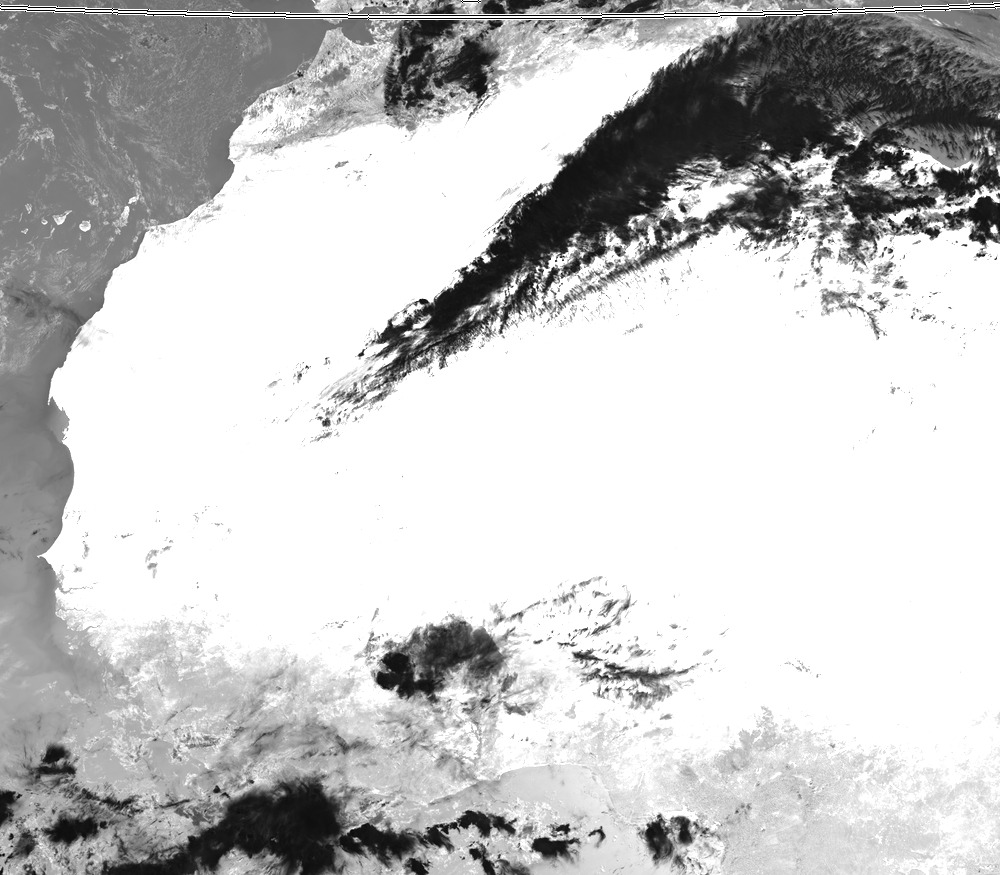

In [68]:
output = "RESULTS/tailor/"  # dossier de sortie
im5 = Image.open(output + 'fichier.jpg', 'r')
display(im5)

Autres exemple de requête : </br>
toutes les bandes du dernier slot FCI Level 1c Normal Resolution Image Data - MTG - 0 degree, geotiff, zone western_europe </br>
!eumdac download -c EO:EUM:DAT:0662 --limit 1 --chain "product: FCIL1FDHSI, format: geotiff, filter: fcil1fdhsi_1km, roi: western_europe" --output ~/MF_DATA_MANIPULATION/CHUNKS/

**Remarque** : </br>
Les produits FCI RGB, c'est à dire de niveau L1.5, ne sont pas disponibles dans le tailor : exemple GeoColour RGB - MTG - 0 degree : 0913 (https://data.eumetsat.int/product/EO:EUM:DAT:0913#)

In [ ]:
!eumdac search -c EO:EUM:DAT:0913 --limit 1